#  Ejercicio 1: Análisis de una red social (Facebook)

*Descripción:* En esta práctica se analizará una red social real. Cada nodo representa un usuario y cada arista representa una relación de amistad entre dos usuarios.

El objetivo es caracterizar la estructura de la red utilizando herramientas de análisis de redes complejas.

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

## 1. Análisis de componentes

- Determina el número de componentes conexas de la red.
- Identifica la componente conexa más grande (componente gigante).
- Calcula el tamaño de la componente gigante y el porcentaje de nodos que contiene respecto al total de la red

In [11]:
G = nx.read_edgelist("facebook_combined.txt", create_using=nx.Graph(), nodetype=int)

#Número de componentes conexas
componentes_conexas = list(nx.connected_components(G))
print("El número de componentes conexas de G es:", len(componentes_conexas))

El número de componentes conexas de G es: 1


In [20]:
print("Número total de nodos:", nx.number_of_nodes(G))
print("Número total de aristas:", nx.number_of_edges(G))

Número total de nodos: 4039
Número total de aristas: 88234


Preguntas:

- ¿Existe una componente gigante?

    Sí.

- ¿Qué proporción de la red contiene?

    1


- ¿La red está mayormente conectada o fragmentada?

    Mayormente conectada.

## 2. Caminos más cortos y efecto de mundo pequeño

- Trabaja únicamente con la componente gigante.
- Calcula la distancia promedio entre pares de nodos (longitud media del camino más corto).
- Calcula el diámetro de la red.

In [18]:
#distancia promedio

dprom = nx.average_shortest_path_length(G)

print("La distancia promedio de la gráfica G es", dprom)

La distancia promedio de la gráfica G es 3.6925068496963913


In [19]:
#diámetro de la red

diam = nx.diameter(G)

print("El diámetro de la gráfica G es", diam)

El diámetro de la gráfica G es 8


Preguntas:

- ¿La distancia media es pequeña en comparación con el tamaño de la red?

    Sí.

- ¿Se observa evidencia del efecto de mundo pequeño?

    Sí.

- ¿Qué diferencia conceptual hay entre distancia media y diámetro?

    La distancia media es el promedio de los caminos más cortos entre todos los pares posibles de nodos, en cambio, el diámetro es el camino corto más largo de todos los caminos cortos.

## 3. Distribución de grado

- Calcula el grado de todos los nodos.
- Construye la distribución de grado pk.
- Realiza una gráfica de la distribución de grado.
- Repite la gráfica en escala log-log.

In [ ]:
#grado de los nodos

grados_dict = dict(G.degree())

for nodo, grado in grados_dict.items():
    print(f"{nodo} tiene {grado} grados.")

0 tiene 347 grados.
1 tiene 17 grados.
2 tiene 10 grados.
3 tiene 17 grados.
4 tiene 10 grados.
5 tiene 13 grados.
6 tiene 6 grados.
7 tiene 20 grados.
8 tiene 8 grados.
9 tiene 57 grados.
10 tiene 10 grados.
11 tiene 1 grados.
12 tiene 1 grados.
13 tiene 31 grados.
14 tiene 15 grados.
15 tiene 1 grados.
16 tiene 9 grados.
17 tiene 13 grados.
18 tiene 1 grados.
19 tiene 16 grados.
20 tiene 15 grados.
21 tiene 65 grados.
22 tiene 11 grados.
23 tiene 17 grados.
24 tiene 16 grados.
25 tiene 69 grados.
26 tiene 68 grados.
27 tiene 5 grados.
28 tiene 13 grados.
29 tiene 13 grados.
30 tiene 17 grados.
31 tiene 23 grados.
32 tiene 6 grados.
33 tiene 2 grados.
34 tiene 5 grados.
35 tiene 2 grados.
36 tiene 11 grados.
37 tiene 1 grados.
38 tiene 9 grados.
39 tiene 15 grados.
40 tiene 44 grados.
41 tiene 24 grados.
42 tiene 2 grados.
43 tiene 1 grados.
44 tiene 6 grados.
45 tiene 12 grados.
46 tiene 5 grados.
47 tiene 2 grados.
48 tiene 22 grados.
49 tiene 4 grados.
50 tiene 11 grados.
51 tiene 

In [55]:
#distribución pk
from collections import Counter

coeficientes_grados = list(grados_dict.values())
N = G.number_of_nodes()

frecuencia = Counter(coeficientes_grados)

x = sorted(frecuencia.keys())
y = [frecuencia[k] / N for k in x]

print("La distribución de grado es", y)

La distribución de grado es [0.018568952711067097, 0.024263431542461005, 0.0230255013617232, 0.024511017578608567, 0.0230255013617232, 0.024263431542461005, 0.024263431542461005, 0.027482050012379303, 0.02475860361475613, 0.02352067343401832, 0.020054468927952464, 0.020302054964100025, 0.01955929685565734, 0.02153998514483783, 0.026244119831641495, 0.020302054964100025, 0.018816538747214655, 0.018073780638771974, 0.017826194602624412, 0.01559792027729636, 0.012874473879673186, 0.01559792027729636, 0.013122059915820748, 0.014855162168853677, 0.01361723198811587, 0.01386481802426343, 0.012131715771230503, 0.009160683337459768, 0.009408269373607328, 0.009903441445902451, 0.009408269373607328, 0.010893785590492696, 0.008665511265164644, 0.010646199554345134, 0.008913097301312206, 0.010646199554345134, 0.010646199554345134, 0.010893785590492696, 0.007179995048279277, 0.006684822975984155, 0.007179995048279277, 0.005199306759098787, 0.007179995048279277, 0.005199306759098787, 0.0047041346868

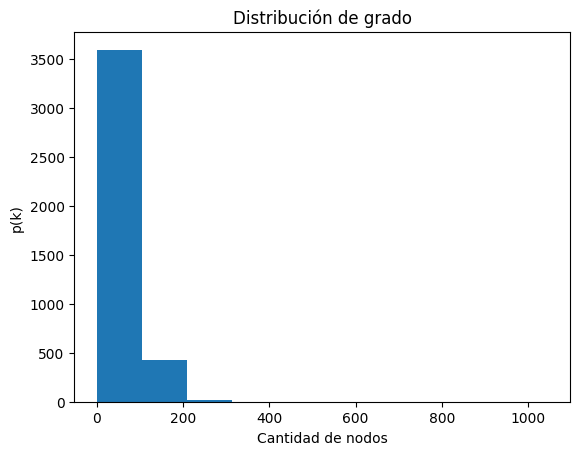

In [60]:
plt.hist(coeficientes_grados)
plt.xlabel("Cantidad de nodos")
plt.ylabel("p(k)")
plt.title("Distribución de grado")
plt.show()

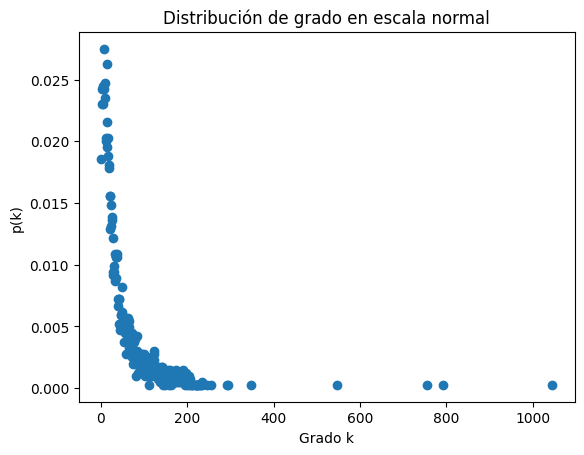

In [58]:
#Gráfica de la distribución de grado en escala normal
plt.scatter(x, y)
plt.xlabel("Grado k")
plt.ylabel("p(k)")
plt.title("Distribución de grado en escala normal")
plt.show()

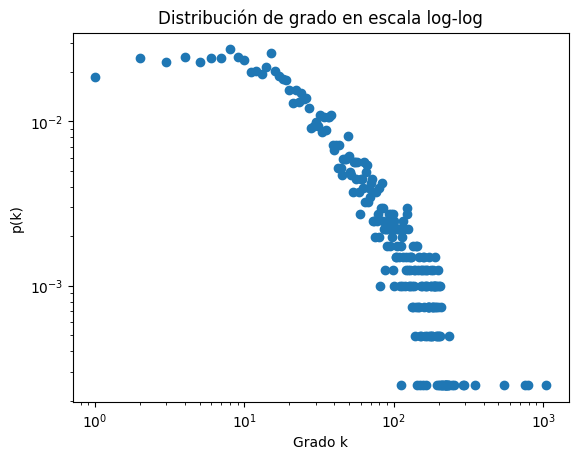

In [53]:
plt.scatter(x, y)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Grado k")
plt.ylabel("p(k)")
plt.title("Distribución de grado en escala log-log")
plt.show()

Preguntas:

- ¿La mayoría de los nodos tiene grado bajo?

    Sí.

- ¿Existen nodos altamente conectados (hubs)?

    Sí.

- ¿La distribución presenta una cola pesada?

    Sí.

- ¿La gráfica en escala log-log sugiere comportamiento de ley de potencia?

    Sí.
    

## 4. Coeficiente de agrupamiento (clustering)

- Calcula el coeficiente de clustering global de la red.
- Calcula el coeficiente de clustering local para cada nodo.
- Analiza la distribución de clustering local.

In [44]:
#coef de de clustering

print("El coeficiente de clustering global es:", nx.average_clustering(G))

El coeficiente de clustering global es: 0.6055467186200862


In [45]:
#clustering local

clustlocal = dict(nx.clustering(G))
clustlocal

{0: 0.04196165314587463,
 1: 0.41911764705882354,
 2: 0.8888888888888888,
 3: 0.6323529411764706,
 4: 0.8666666666666667,
 5: 0.3333333333333333,
 6: 0.9333333333333333,
 7: 0.43157894736842106,
 8: 0.6785714285714286,
 9: 0.39724310776942356,
 10: 0.8222222222222222,
 11: 0,
 12: 0,
 13: 0.6516129032258065,
 14: 0.7428571428571429,
 15: 0,
 16: 0.6666666666666666,
 17: 0.7307692307692307,
 18: 0,
 19: 0.2833333333333333,
 20: 0.6857142857142857,
 21: 0.3490384615384615,
 22: 0.4727272727272727,
 23: 0.16911764705882354,
 24: 0.9,
 25: 0.2885763000852515,
 26: 0.4113257243195786,
 27: 0.9,
 28: 0.7692307692307693,
 29: 0.46153846153846156,
 30: 0.5,
 31: 0.43478260869565216,
 32: 1.0,
 33: 1.0,
 34: 0.6,
 35: 1.0,
 36: 0.9636363636363636,
 37: 0,
 38: 0.3611111111111111,
 39: 0.49523809523809526,
 40: 0.4048625792811839,
 41: 0.4673913043478261,
 42: 1.0,
 43: 0,
 44: 1.0,
 45: 0.7272727272727273,
 46: 1.0,
 47: 1.0,
 48: 0.329004329004329,
 49: 0.5,
 50: 0.5636363636363636,
 51: 0.857

In [63]:
coeficientes_clust = list(clustlocal.values())
N1 = nx.average_clustering(G)

frecuencia2 = Counter(coeficientes_clust)

x = sorted(frecuencia2.keys())
y = [frecuencia2[k] / N1 for k in x]


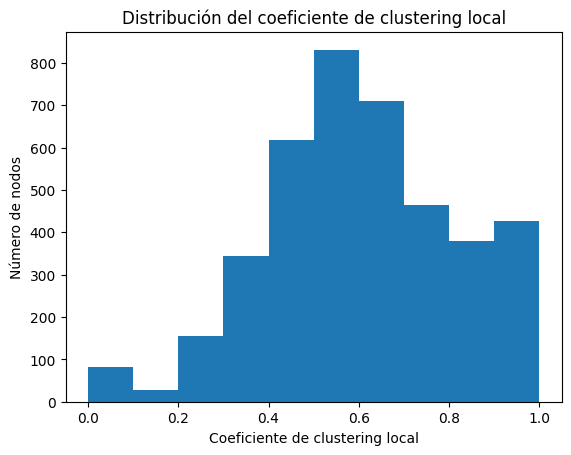

In [62]:

plt.hist(coeficientes_clust)
plt.xlabel("Coeficiente de clustering local")
plt.ylabel("Número de nodos")
plt.title("Distribución del coeficiente de clustering local")
plt.show()

Preguntas:

- ¿El valor del clustering global es alto o bajo?

    Alto.

- ¿Qué indica esto sobre la estructura local de la red?

    Que existen muchos triángulos, lo que se puede interpretar como que los vecinos de un nodo es muy probable que también sean vecinos entre ellos. 

- ¿Es probable que los amigos de un nodo también sean amigos entre sí?

    Sí.



## 5. Interpretación global

Redacta una descripción de la red respondiendo:

- ¿La red tiene una componente gigante?
- ¿Presenta efecto de mundo pequeño?
- ¿Existen hubs?
- ¿El clustering es alto?
- ¿Qué tipo de estructura global parece tener la red?


La red creada a partir de la lista de amigos de usuarios de Faceboook tiene una componente gigante, la cual es ella misma en su totalidad. De sus características, podemos destacar que su distancia promedio es de aproximadamente 3.7 y su diámetro, de 8. Lo que puede indicar presencia del efecto de mundo pequeño.

Por otra parte, al analizar las gráficas de su distribución de grado, notamos una cola pesada en la gráfica a escala normal, mientras que, en la escala log-log, se aprecian unos puntos muy apartados del resto. Lo que puede indicar que existen hubs en la red.

Sobre el coeficiente de clustering global, se encontró que es de aproximadamente 0.60. Es decir, el número de triángulos en la red es considerable. 

